**1. Data Import & Understanding**

1.1 - Dataset Preview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure charts look nice
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# 1. Load the Data
# Ensure 'weatherAUS.csv' is in the same folder as this notebook
df = pd.read_csv('weatherAUS.csv')

# 2. Quick Look
print(f"Dataset Shape: {df.shape}")  # Shows (Rows, Columns)
df.head()

Dataset Shape: (145460, 23)


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


<Figure size 1000x600 with 0 Axes>

1.2 - Structure & Missing Values Analysis

--- Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am  

C:\Users\JulianYip\AppData\Local\Temp\ipykernel_14380\3232239977.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_percent.index, y=missing_percent.values, palette="viridis")


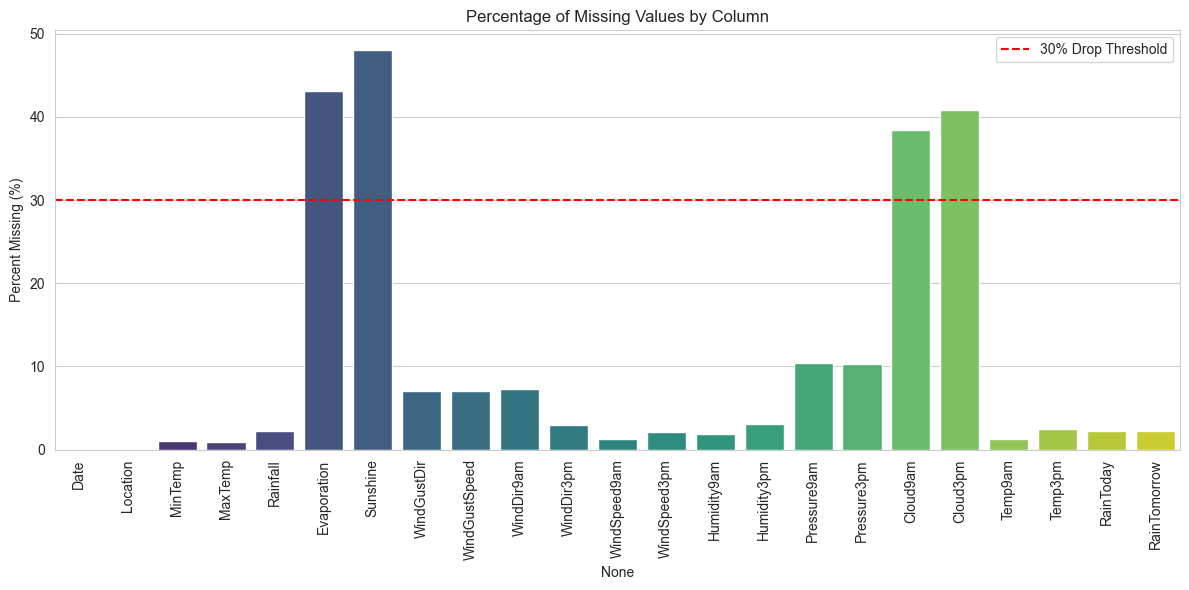

In [2]:
# 1. Check Data Types
print("--- Data Types ---")
print(df.info())

# 2. Calculate Missing Values Percentage
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

# Create a clean table for your report
missing_table = pd.DataFrame({
    'Missing Values': missing,
    'Percentage (%)': missing_percent
}).sort_values(by='Percentage (%)', ascending=False)

# Display columns that actually have missing data
print("\n--- Missing Data Breakdown ---")
print(missing_table[missing_table['Percentage (%)'] > 0])

# 3. Visualize Missing Data (Great chart for Task 2 Report)
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_percent.index, y=missing_percent.values, palette="viridis")
plt.xticks(rotation=90)
plt.title("Percentage of Missing Values by Column")
plt.ylabel("Percent Missing (%)")
plt.axhline(y=30, color='r', linestyle='--', label='30% Drop Threshold') # Threshold line
plt.legend()
plt.tight_layout()
plt.show()

1.3 - Target Variable Analysis (Class Imbalance)

--- Target Variable Distribution ---
RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64

No Rain: 75.84%
Rain:    21.91%


C:\Users\JulianYip\AppData\Local\Temp\ipykernel_14380\901439556.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  no_rain_perc = (target_counts[0] / len(df)) * 100
C:\Users\JulianYip\AppData\Local\Temp\ipykernel_14380\901439556.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  yes_rain_perc = (target_counts[1] / len(df)) * 100
C:\Users\JulianYip\AppData\Local\Temp\ipykernel_14380\901439556.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='RainTomorrow', dat

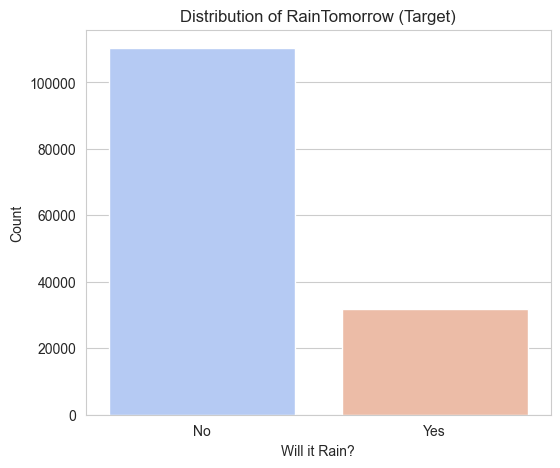

In [3]:
# Check the counts of the Target Variable
target_counts = df['RainTomorrow'].value_counts()
print("--- Target Variable Distribution ---")
print(target_counts)

# Calculate percentage
no_rain_perc = (target_counts[0] / len(df)) * 100
yes_rain_perc = (target_counts[1] / len(df)) * 100

print(f"\nNo Rain: {no_rain_perc:.2f}%")
print(f"Rain:    {yes_rain_perc:.2f}%")

# Plot
plt.figure(figsize=(6, 5))
sns.countplot(x='RainTomorrow', data=df, palette='coolwarm')
plt.title("Distribution of RainTomorrow (Target)")
plt.xlabel("Will it Rain?")
plt.ylabel("Count")
plt.show()

1.4 - Correlation Heatmap

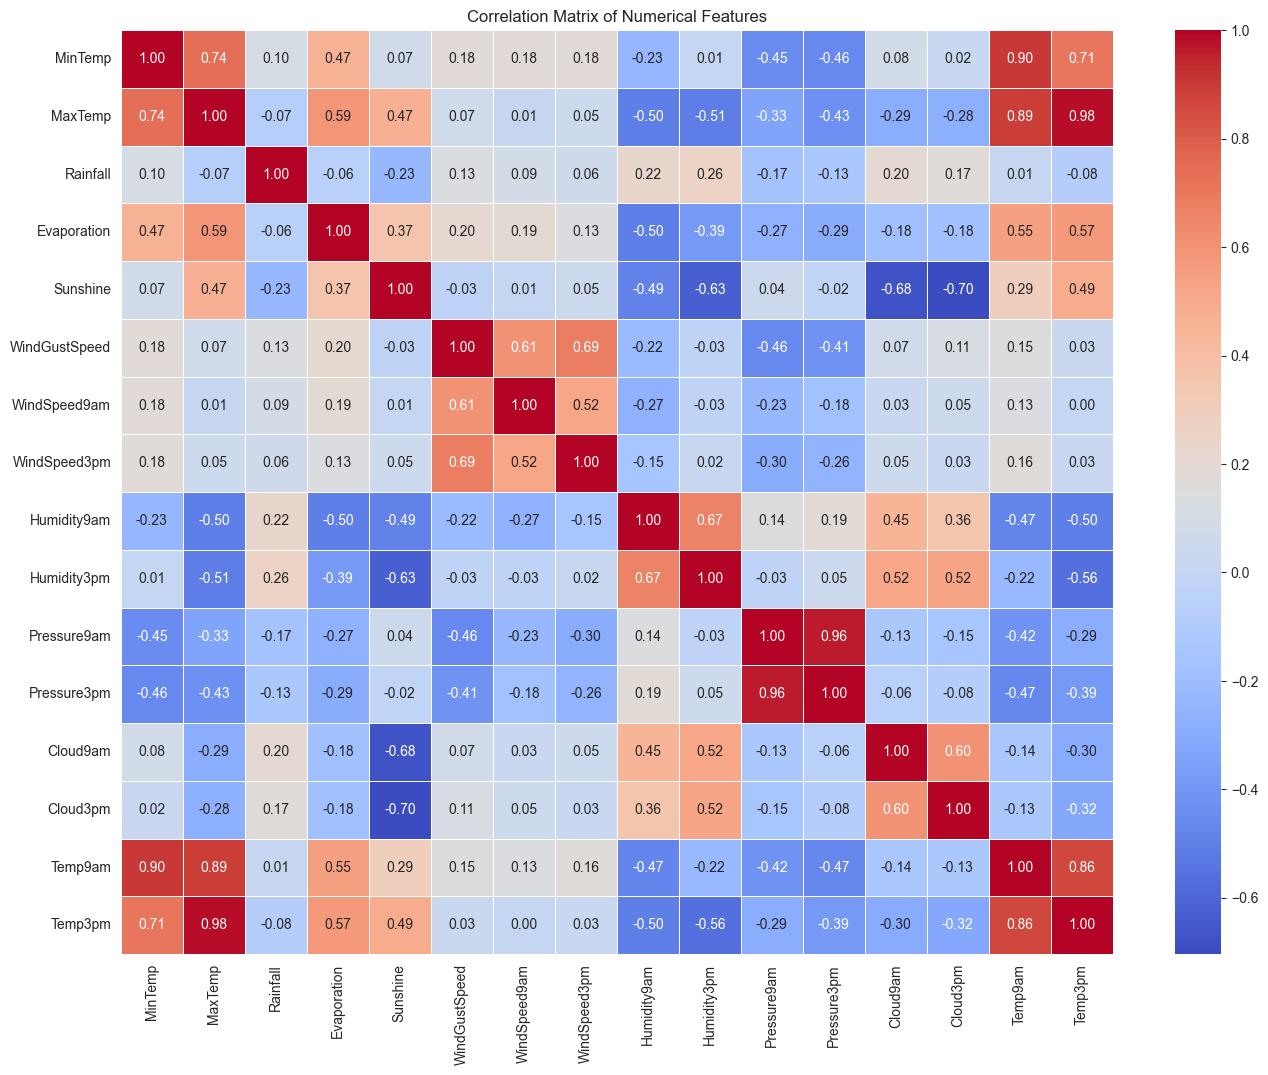

In [4]:
# 1. Filter only numerical columns for correlation
# (We drop columns with high missing values first for a cleaner chart)
numeric_df = df.select_dtypes(include=[np.number])

# 2. Calculate Correlation
corr_matrix = numeric_df.corr()

# 3. Plot Heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

**2. Data Preprocessing**

2.1 - Basic Cleaning

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# ==========================================
# PHASE 1: CLEANING & ENCODING (OPTIMIZED)
# ==========================================

original_shape = df.shape

# 1. Removing columns with ~40-50% missing data
cols_to_drop = ['Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm']
df.drop(columns=cols_to_drop, inplace=True)
print(f"Dropped columns: {cols_to_drop}")

# 2. Remove NA rows for target variable
df.dropna(subset=['RainTomorrow'], inplace=True)

# 3. Imputing NA (missing values)
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median()) 

categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values filled.")

# 4. Encoding binary columns (Yes/No -> 0/1)
le = LabelEncoder()
df['RainToday'] = le.fit_transform(df['RainToday'])
df['RainTomorrow'] = le.fit_transform(df['RainTomorrow'])

# 5. ENCODING WIND DIRECTION (The "Sin/Cos" Fix)
# First, turn directions (N, W) into Numbers (0-15)
direction_cols = ['WindGustDir', 'WindDir9am', 'WindDir3pm']
for col in direction_cols:
    df[col] = le.fit_transform(df[col])
    
    # apply the Math Fix: Convert 0-15 into Circle Coordinates
    # This prevents the model from thinking "North-West (15)" is greater than "North (0)"
    df[col + '_Sin'] = np.sin(2 * np.pi * df[col] / 16.0)
    df[col + '_Cos'] = np.cos(2 * np.pi * df[col] / 16.0)
    
    # Drop the original integer column so the model only sees the Sin/Cos pairs
    df.drop(columns=[col], inplace=True)

print("Wind columns successfully converted to Cyclical Features (Sin/Cos).")

# 6. Encoding location columns (One-Hot Encoding)
df = pd.get_dummies(df, columns=['Location'], drop_first=True)

print("\n" + "="*30)
print("PHASE 1 COMPLETE")
print("="*30)
print(f"Original Shape: {original_shape}")
print(f"New Shape:      {df.shape}")
print("Check the first 5 rows below. You should see '_Sin' and '_Cos' columns now.")
df.head()

Dropped columns: ['Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm']
Missing values filled.
Wind columns successfully converted to Cyclical Features (Sin/Cos).

PHASE 1 COMPLETE
Original Shape: (145460, 23)
New Shape:      (142193, 69)
Check the first 5 rows below. You should see '_Sin' and '_Cos' columns now.


,Date,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,...,Location_Townsville,Location_Tuggeranong,Location_Uluru,Location_WaggaWagga,Location_Walpole,Location_Watsonia,Location_Williamtown,Location_Witchcliffe,Location_Wollongong,Location_Woomera
0,2008-12-01,13.4,22.9,0.6,44.0,20.0,24.0,71.0,22.0,1007.7,...,False,False,False,False,False,False,False,False,False,False
1,2008-12-02,7.4,25.1,0.0,44.0,4.0,22.0,44.0,25.0,1010.6,...,False,False,False,False,False,False,False,False,False,False
2,2008-12-03,12.9,25.7,0.0,46.0,19.0,26.0,38.0,30.0,1007.6,...,False,False,False,False,False,False,False,False,False,False
3,2008-12-04,9.2,28.0,0.0,24.0,11.0,9.0,45.0,16.0,1017.6,...,False,False,False,False,False,False,False,False,False,False
4,2008-12-05,17.5,32.3,1.0,41.0,7.0,20.0,82.0,33.0,1010.8,...,False,False,False,False,False,False,False,False,False,False


2.2 - Preparing for the Model 


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

print("--- PHASE 2: DEEP LEARNING PREPARATION (WITH DATES) ---")

# 1. SORT BY DATE
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')

# === SAVE DATES BEFORE DROPPING ===
dates = df['Date'].values 
df.drop(columns=['Date'], inplace=True)
print("Dates saved and column dropped.")

# 2. DEFINE FEATURES AND SCALE
X = df.drop(columns=['RainTomorrow']).values
y = df['RainTomorrow'].values

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# 3. SLIDING WINDOW 
# need to window the dates so they match the X and y rows
def create_sequences_with_dates(data, target, dates, time_steps=7):
    Xs, ys, ds = [], [], []
    for i in range(len(data) - time_steps):
        Xs.append(data[i:(i + time_steps)])
        ys.append(target[i + time_steps])
        ds.append(dates[i + time_steps]) # Match date to target
    return np.array(Xs), np.array(ys), np.array(ds)

TIME_STEPS = 7
print(f"Reshaping data (Window Size: {TIME_STEPS})...")
X_lstm, y_lstm, dates_lstm = create_sequences_with_dates(X_scaled, y, dates, TIME_STEPS)

# 4. SPLIT TRAIN/TEST
train_size = int(len(X_lstm) * 0.8)

X_train, X_test = X_lstm[:train_size], X_lstm[train_size:]
y_train, y_test = y_lstm[:train_size], y_lstm[train_size:]

# We also split the dates so we know which dates correspond to X_test
dates_train, dates_test = dates_lstm[:train_size], dates_lstm[train_size:]

print("\nPREPROCESSING COMPLETE")
print(f"X_train shape: {X_train.shape}")
print(f"Test Dates:    {len(dates_test)} (Ready for plotting!)")

--- PHASE 2: DEEP LEARNING PREPARATION (WITH DATES) ---
Dates saved and column dropped.
Reshaping data (Window Size: 7)...

PREPROCESSING COMPLETE
X_train shape: (113748, 7, 67)
Test Dates:    28438 (Ready for plotting!)


**3. MODEL TRAINING**


3.1 - LSTM Base Model

--- TRAINING BASE MODEL (Standard settings, Imbalanced Data) ---


c:\Users\JulianYip\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
1778/1778 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.7745 - loss: 0.5233 - val_accuracy: 0.7758 - val_loss: 0.5085
Epoch 2/15
1778/1778 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.7756 - loss: 0.5172 - val_accuracy: 0.7767 - val_loss: 0.5105
Epoch 3/15
1778/1778 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.7757 - loss: 0.5152 - val_accuracy: 0.7763 - val_loss: 0.5061
Epoch 4/15
1778/1778 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.7756 - loss: 0.5141 - val_accuracy: 0.7763 - val_loss: 0.5074
Epoch 5/15
1778/1778 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.7760 - loss: 0.5131 - val_accuracy: 0.7765 - val_loss: 0.5055
Epoch 6/15
1778/1778 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.7759 - loss: 0.5118 - val_accuracy: 0.7768 - val_loss: 0.5047
Epoch 7/15
1778/1778 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.7764 - loss: 0.5103 - val_accuracy: 0.7767 - val_loss: 0.5045
Epoch 8/15
1778/1778 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.7763 - loss: 

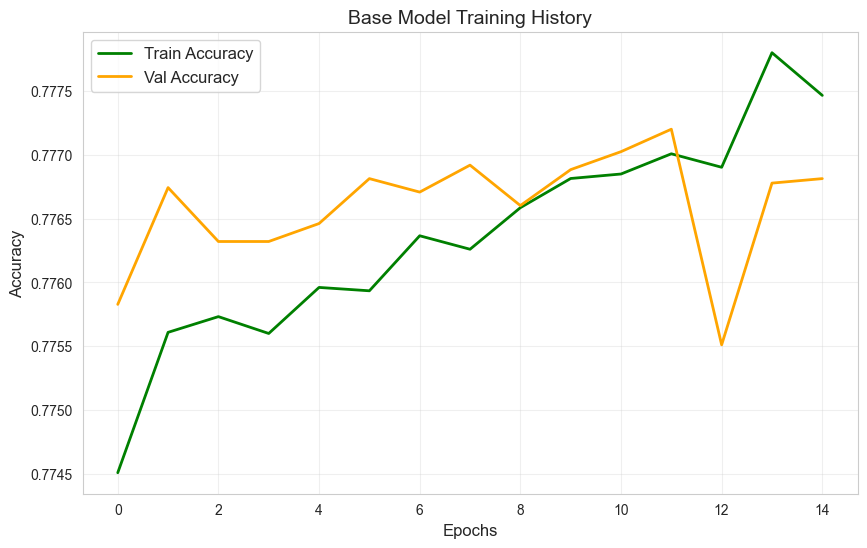

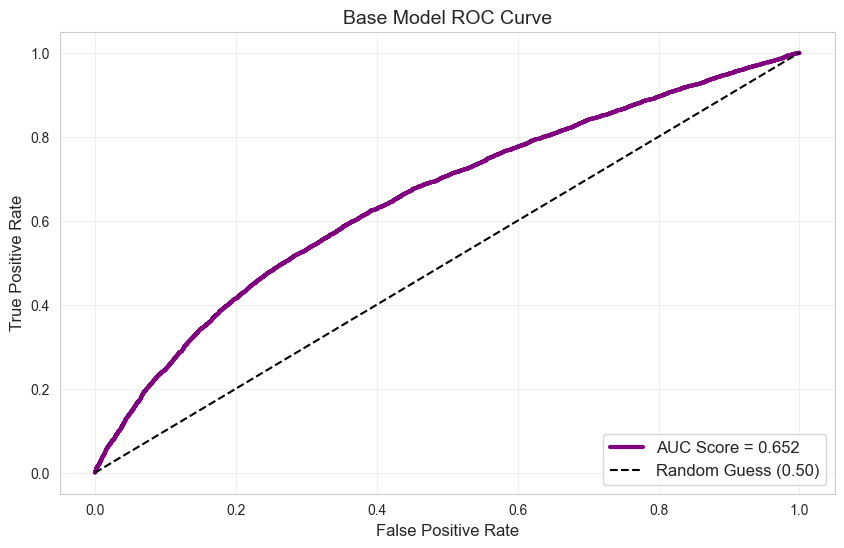

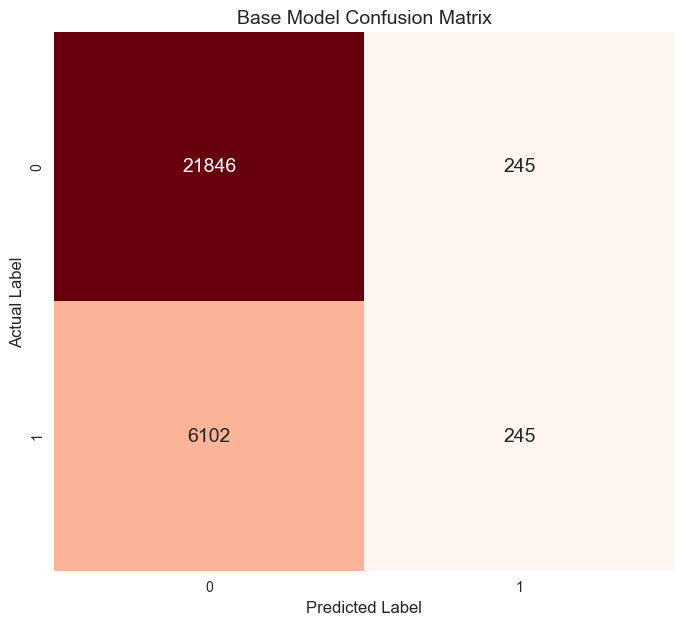

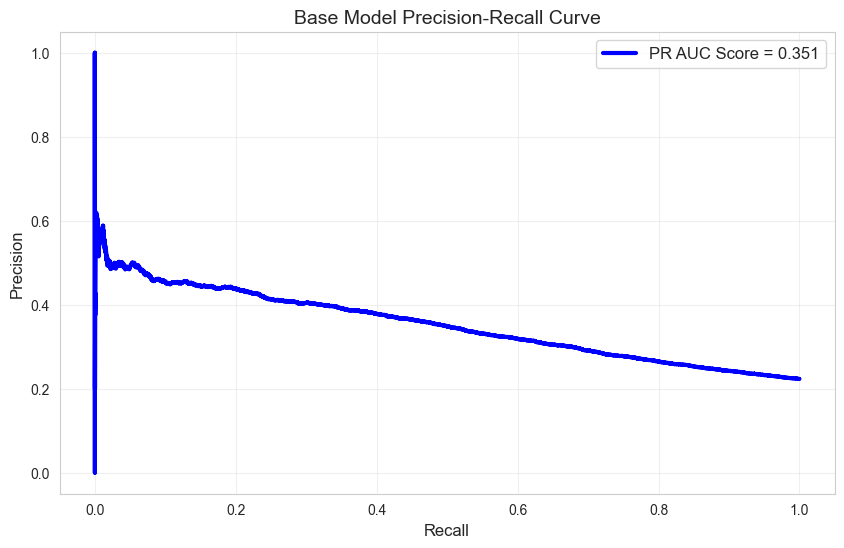

In [ ]:
# ==========================================
# TASK 1: BASE LSTM MODEL (Unoptimized)
# ==========================================
from tensorflow.keras.models import Sequential # build the model by layer
from tensorflow.keras.layers import LSTM, Dense, Dropout # the required layers
from tensorflow.keras.optimizers import Adam # optimizer
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, precision_recall_curve, auc # metrics
import matplotlib.pyplot as plt # plotting graphs
import seaborn as sns # developing complex/nicer graphs
import numpy as np # numerical operations

print("--- TRAINING BASE MODEL (Standard settings, Imbalanced Data) ---")

# 1. GET SHAPES # how many days and features
n_timesteps = X_train.shape[1]
n_features = X_train.shape[2]

# 2. Basic Architecture
model_base = Sequential([
    # LSTM Layer: 64 internal units to learn time patterns
    LSTM(64, input_shape=(n_timesteps, n_features)), 
    Dropout(0.2), # to prevent overfitting
    Dense(1, activation='sigmoid') # gets a probability between 0 & 1
])

# Standard Learning Rate (0.001 is default for Adam)
model_base.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. Model Training Process
history_base = model_base.fit(X_train, y_train, 
                              epochs=15, 
                              batch_size=64, 
                              validation_data=(X_test, y_test), 
                              verbose=1)

# 4. Generate Predictions (Default Threshold 0.5)
y_probs_base = model_base.predict(X_test)
y_pred_base = (y_probs_base > 0.5).astype(int)

# ==========================================
# PLOTTING & EVALUATION (INDIVIDUAL PLOTS)
# ==========================================
print("\n" + "="*40)
print(f"BASE MODEL METRICS (Threshold 0.5)")
print("="*40)
print(classification_report(y_test, y_pred_base))

# --- PLOT 1: TRAINING HISTORY ---
plt.figure(figsize=(10, 6))
plt.plot(history_base.history['accuracy'], label='Train Accuracy', color='green', linewidth=2)
plt.plot(history_base.history['val_accuracy'], label='Val Accuracy', color='orange', linewidth=2)
plt.title('Base Model Training History', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show() # Shows Plot 1 alone

# --- PLOT 2: ROC CURVE ---
fpr, tpr, _ = roc_curve(y_test, y_probs_base)
roc_auc = roc_auc_score(y_test, y_probs_base)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='purple', linewidth=3, label=f'AUC Score = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (0.50)') 
plt.title('Base Model ROC Curve', fontsize=14)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show() # Shows Plot 2 alone

# --- PLOT 3: CONFUSION MATRIX ---
plt.figure(figsize=(8, 7))
cm = confusion_matrix(y_test, y_pred_base)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False, annot_kws={"size": 14})
plt.title('Base Model Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.show() # Shows Plot 3 alone

# --- PLOT 4: PRECISION-RECALL CURVE ---
precision, recall, _ = precision_recall_curve(y_test, y_probs_base)
pr_auc = auc(recall, precision)

plt.figure(figsize=(10, 6))
plt.plot(recall, precision, color='blue', linewidth=3, label=f'PR AUC Score = {pr_auc:.3f}')
plt.title('Base Model Precision-Recall Curve', fontsize=14)
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show() # Shows Plot 4 alone

3.2 - Hyperparameter Tuned LSTM

--- STEP 1: PREPARING DATA (SMOTE) ---
SMOTE Complete. Training Data Shape: (176444, 7, 67)

--- STEP 2: TRAINING FINAL MODEL ---


c:\Users\JulianYip\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
2757/2757 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - accuracy: 0.5646 - loss: 0.6792 - val_accuracy: 0.5985 - val_loss: 0.6600
Epoch 2/30
2757/2757 ━━━━━━━━━━━━━━━━━━━━ 41s 15ms/step - accuracy: 0.6037 - loss: 0.6611 - val_accuracy: 0.6289 - val_loss: 0.6347
Epoch 3/30
2757/2757 ━━━━━━━━━━━━━━━━━━━━ 43s 15ms/step - accuracy: 0.6470 - loss: 0.6333 - val_accuracy: 0.6455 - val_loss: 0.6326
Epoch 4/30
2757/2757 ━━━━━━━━━━━━━━━━━━━━ 43s 15ms/step - accuracy: 0.7193 - loss: 0.5565 - val_accuracy: 0.7032 - val_loss: 0.5943
Epoch 5/30
2757/2757 ━━━━━━━━━━━━━━━━━━━━ 47s 17ms/step - accuracy: 0.7559 - loss: 0.4938 - val_accuracy: 0.7492 - val_loss: 0.5471
Epoch 6/30
2757/2757 ━━━━━━━━━━━━━━━━━━━━ 62s 22ms/step - accuracy: 0.7746 - loss: 0.4593 - val_accuracy: 0.7733 - val_loss: 0.5177
Epoch 7/30
2757/2757 ━━━━━━━━━━━━━━━━━━━━ 53s 19ms/step - accuracy: 0.7865 - loss: 0.4392 - val_accuracy: 0.7678 - val_loss: 0.5242
Epoch 8/30
2757/2757 ━━━━━━━━━━━━━━━━━━━━ 58s 21ms/step - accuracy: 0.7923 -

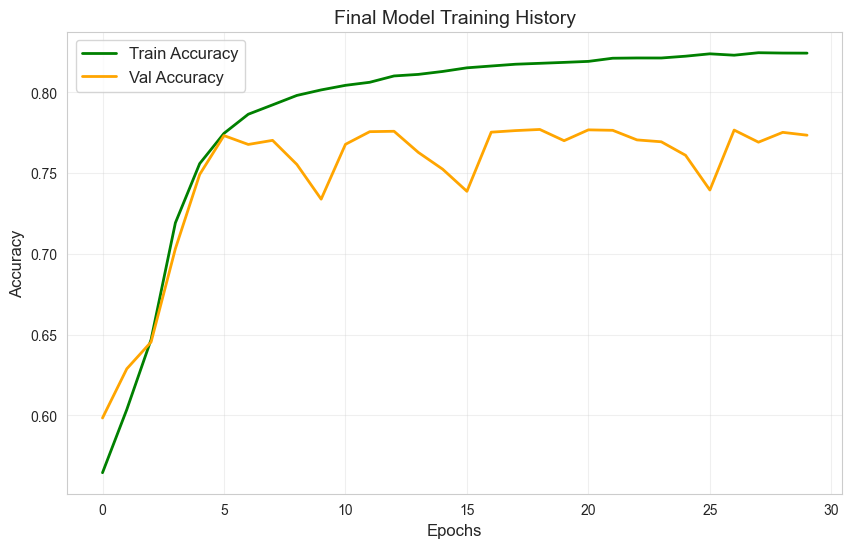

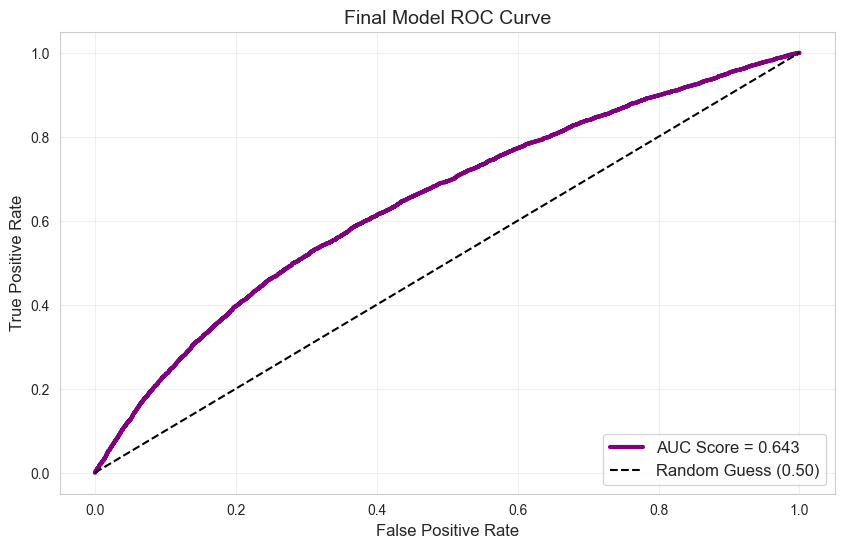

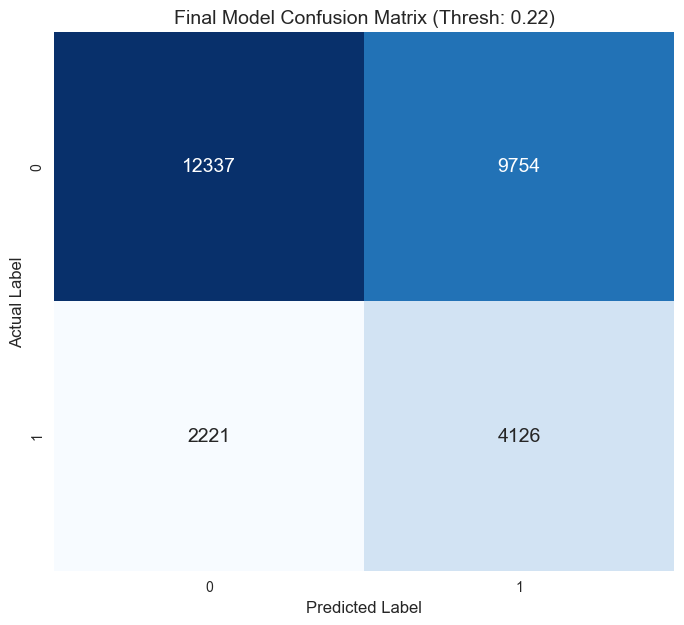

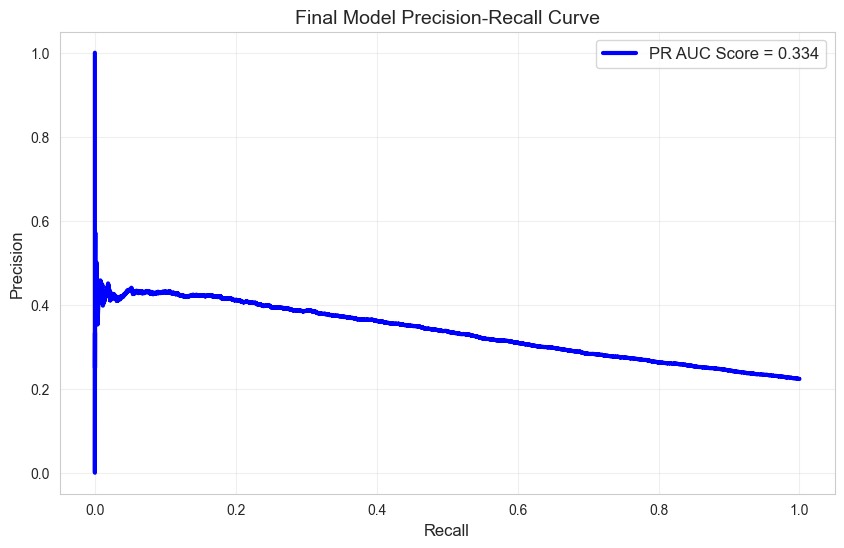

In [12]:
# ==========================================
# TASK 2: FINAL TUNED LSTM MODEL (COMPLETE)
# ==========================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import f1_score, classification_report, confusion_matrix, roc_curve, roc_auc_score, precision_recall_curve, auc
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("--- STEP 1: PREPARING DATA (SMOTE) ---")
# 1. Flatten Data for SMOTE
n_samples, n_timesteps, n_features = X_train.shape
X_train_flat = X_train.reshape((n_samples, n_timesteps * n_features))

# 2. Apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_flat, y_train)

# 3. Reshape back to 3D for LSTM
X_train_smote_3d = X_train_smote.reshape((X_train_smote.shape[0], n_timesteps, n_features))
print(f"SMOTE Complete. Training Data Shape: {X_train_smote_3d.shape}")

print("\n--- STEP 2: TRAINING FINAL MODEL ---")
# 4. Define Tuned Architecture
model_tuned = Sequential([
    LSTM(64, return_sequences=True, input_shape=(n_timesteps, n_features)),
    Dropout(0.3),
    LSTM(32, return_sequences=False),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

# 5. Train with Optimized Learning Rate
opt = Adam(learning_rate=0.0001)
model_tuned.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

history_tuned = model_tuned.fit(X_train_smote_3d, y_train_smote, 
                                epochs=30, 
                                batch_size=64, 
                                validation_data=(X_test, y_test), 
                                verbose=1)

# 6. Optimize Threshold
print("\n--- STEP 3: OPTIMIZING THRESHOLD ---")
y_probs_tuned = model_tuned.predict(X_test)
best_thresh = 0.5
best_f1 = 0.0

for thresh in np.arange(0.1, 0.6, 0.01):
    y_temp = (y_probs_tuned > thresh).astype(int)
    score = f1_score(y_test, y_temp)
    if score > best_f1:
        best_f1 = score
        best_thresh = thresh

print(f"Best Threshold Found: {best_thresh:.2f}")
y_pred_tuned = (y_probs_tuned > best_thresh).astype(int)

# ==========================================
# PLOTTING & EVALUATION (INDIVIDUAL PLOTS)
# ==========================================
print("\n" + "="*40)
print(f"FINAL MODEL METRICS (Threshold {best_thresh:.2f})")
print("="*40)
print(classification_report(y_test, y_pred_tuned))

# --- PLOT 1: TRAINING HISTORY ---
plt.figure(figsize=(10, 6))
plt.plot(history_tuned.history['accuracy'], label='Train Accuracy', color='green', linewidth=2)
plt.plot(history_tuned.history['val_accuracy'], label='Val Accuracy', color='orange', linewidth=2)
plt.title('Final Model Training History', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show() 

# --- PLOT 2: ROC CURVE ---
fpr, tpr, _ = roc_curve(y_test, y_probs_tuned)
roc_auc = roc_auc_score(y_test, y_probs_tuned)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='purple', linewidth=3, label=f'AUC Score = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (0.50)') 
plt.title('Final Model ROC Curve', fontsize=14)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show() 

# --- PLOT 3: CONFUSION MATRIX ---
plt.figure(figsize=(8, 7))
cm = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 14})
plt.title(f'Final Model Confusion Matrix (Thresh: {best_thresh:.2f})', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.show() 

# --- PLOT 4: PRECISION-RECALL CURVE ---
precision, recall, _ = precision_recall_curve(y_test, y_probs_tuned)
pr_auc = auc(recall, precision)

plt.figure(figsize=(10, 6))
plt.plot(recall, precision, color='blue', linewidth=3, label=f'PR AUC Score = {pr_auc:.3f}')
plt.title('Final Model Precision-Recall Curve', fontsize=14)
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

3.3 - GRU Base Model

--- TRAINING BASE GRU (Standard settings, Imbalanced Data) ---


c:\Users\JulianYip\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
1778/1778 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - accuracy: 0.7749 - loss: 0.5225 - val_accuracy: 0.7761 - val_loss: 0.5114
Epoch 2/15
1778/1778 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.7753 - loss: 0.5172 - val_accuracy: 0.7769 - val_loss: 0.5095
Epoch 3/15
1778/1778 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.7757 - loss: 0.5150 - val_accuracy: 0.7762 - val_loss: 0.5069
Epoch 4/15
1778/1778 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.7759 - loss: 0.5132 - val_accuracy: 0.7758 - val_loss: 0.5060
Epoch 5/15
1778/1778 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.7759 - loss: 0.5118 - val_accuracy: 0.7771 - val_loss: 0.5062
Epoch 6/15
1778/1778 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.7763 - loss: 0.5107 - val_accuracy: 0.7768 - val_loss: 0.5043
Epoch 7/15
1778/1778 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.7762 - loss: 0.5098 - val_accuracy: 0.7769 - val_loss: 0.5046
Epoch 8/15
1778/1778 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.7768 -

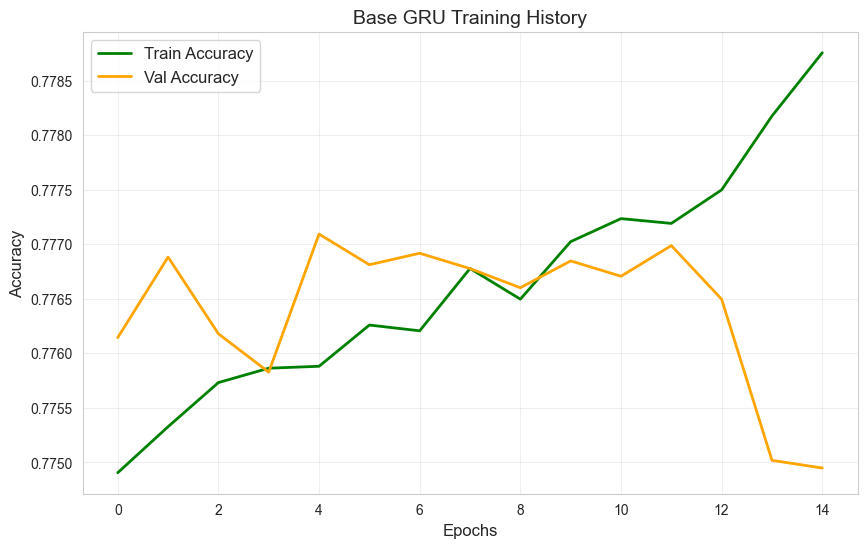

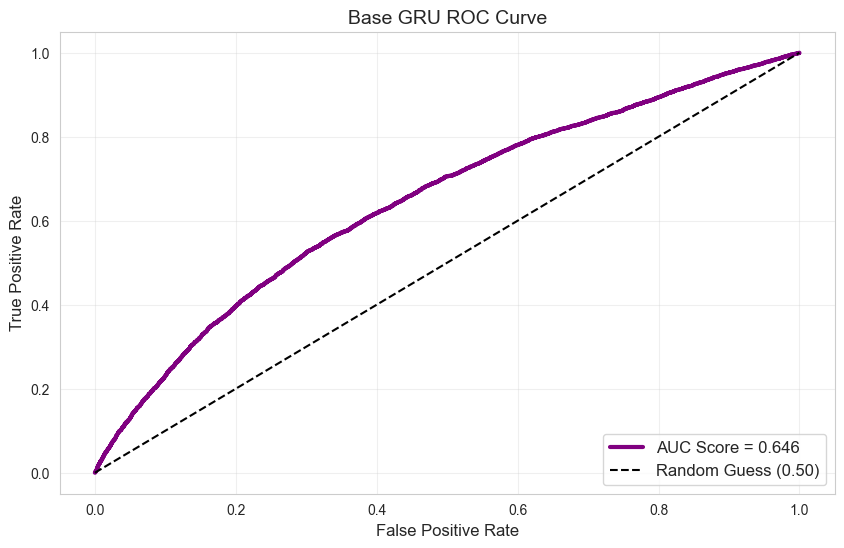

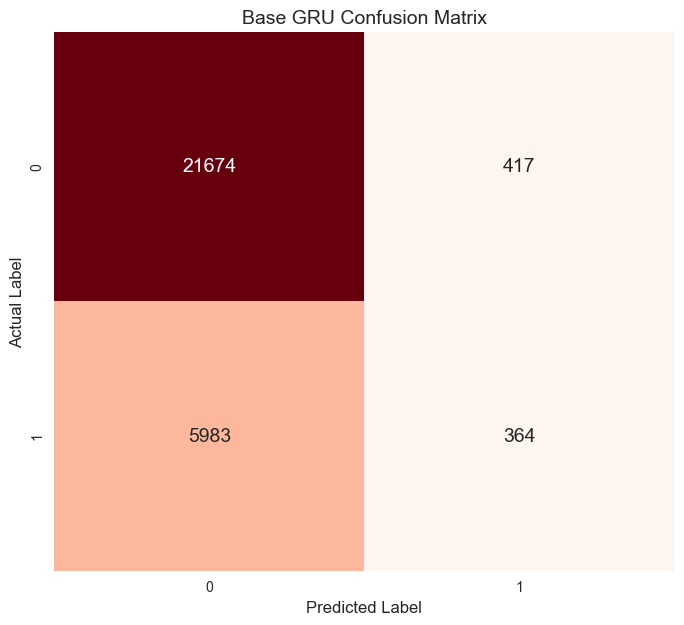

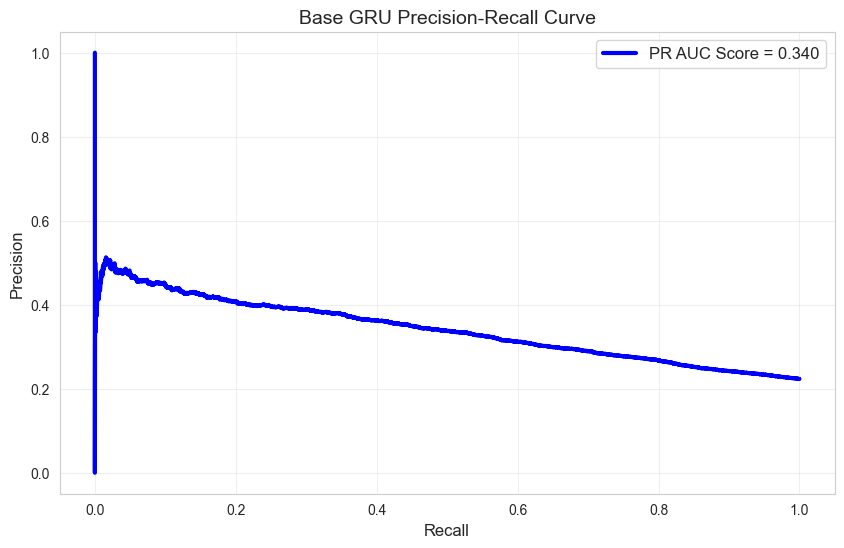

In [ ]:
# ==========================================
# TASK 1 (Model 2): BASE GRU MODEL
# ==========================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

print("--- TRAINING BASE GRU (Standard settings, Imbalanced Data) ---")

# 1. Get Shapes 
n_timesteps = X_train.shape[1]
n_features = X_train.shape[2]

# 2. Basic GRU Architecture
model_gru_base = Sequential([
    GRU(64, input_shape=(n_timesteps, n_features)), 
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model_gru_base.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. Model Training Process
history_gru_base = model_gru_base.fit(X_train, y_train, 
                                      epochs=15, 
                                      batch_size=64, 
                                      validation_data=(X_test, y_test), 
                                      verbose=1)

# 4. Predictions (Default Threshold 0.5)
y_probs_gru_base = model_gru_base.predict(X_test)
y_pred_gru_base = (y_probs_gru_base > 0.5).astype(int)

# ==========================================
# PLOTTING (INDIVIDUAL PLOTS)
# ==========================================
print("\n" + "="*40)
print(f"BASE GRU METRICS (Threshold 0.5)")
print("="*40)
print(classification_report(y_test, y_pred_gru_base))

# --- PLOT 1: TRAINING HISTORY ---
plt.figure(figsize=(10, 6))
plt.plot(history_gru_base.history['accuracy'], label='Train Accuracy', color='green', linewidth=2)
plt.plot(history_gru_base.history['val_accuracy'], label='Val Accuracy', color='orange', linewidth=2)
plt.title('Base GRU Training History', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# --- PLOT 2: ROC CURVE ---
fpr, tpr, _ = roc_curve(y_test, y_probs_gru_base)
roc_auc = roc_auc_score(y_test, y_probs_gru_base)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='purple', linewidth=3, label=f'AUC Score = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (0.50)') 
plt.title('Base GRU ROC Curve', fontsize=14)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# --- PLOT 3: CONFUSION MATRIX ---
plt.figure(figsize=(8, 7))
cm = confusion_matrix(y_test, y_pred_gru_base)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False, annot_kws={"size": 14})
plt.title('Base GRU Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.show()

# --- PLOT 4: PRECISION-RECALL CURVE ---
precision, recall, _ = precision_recall_curve(y_test, y_probs_gru_base)
pr_auc = auc(recall, precision)

plt.figure(figsize=(10, 6))
plt.plot(recall, precision, color='blue', linewidth=3, label=f'PR AUC Score = {pr_auc:.3f}')
plt.title('Base GRU Precision-Recall Curve', fontsize=14)
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

3.4 - Hyperparameter Tuned GRU

--- TRAINING TUNED GRU (SMOTE + Threshold Opt) ---


c:\Users\JulianYip\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
2757/2757 ━━━━━━━━━━━━━━━━━━━━ 53s 17ms/step - accuracy: 0.5608 - loss: 0.6799 - val_accuracy: 0.5452 - val_loss: 0.6825
Epoch 2/30
2757/2757 ━━━━━━━━━━━━━━━━━━━━ 49s 18ms/step - accuracy: 0.6161 - loss: 0.6539 - val_accuracy: 0.5714 - val_loss: 0.6765
Epoch 3/30
2757/2757 ━━━━━━━━━━━━━━━━━━━━ 51s 19ms/step - accuracy: 0.6662 - loss: 0.6169 - val_accuracy: 0.6285 - val_loss: 0.6518
Epoch 4/30
2757/2757 ━━━━━━━━━━━━━━━━━━━━ 54s 19ms/step - accuracy: 0.7271 - loss: 0.5465 - val_accuracy: 0.7535 - val_loss: 0.5454
Epoch 5/30
2757/2757 ━━━━━━━━━━━━━━━━━━━━ 51s 19ms/step - accuracy: 0.7535 - loss: 0.5007 - val_accuracy: 0.6256 - val_loss: 0.7096
Epoch 6/30
2757/2757 ━━━━━━━━━━━━━━━━━━━━ 57s 21ms/step - accuracy: 0.7683 - loss: 0.4727 - val_accuracy: 0.7352 - val_loss: 0.5717
Epoch 7/30
2757/2757 ━━━━━━━━━━━━━━━━━━━━ 51s 19ms/step - accuracy: 0.7782 - loss: 0.4542 - val_accuracy: 0.7536 - val_loss: 0.5480
Epoch 8/30
2757/2757 ━━━━━━━━━━━━━━━━━━━━ 52s 19ms/step - accuracy: 0.7861 -

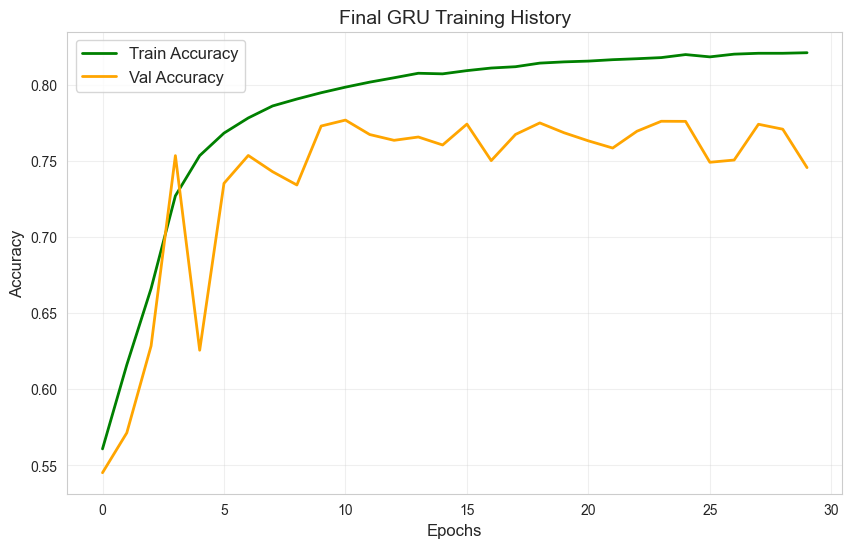

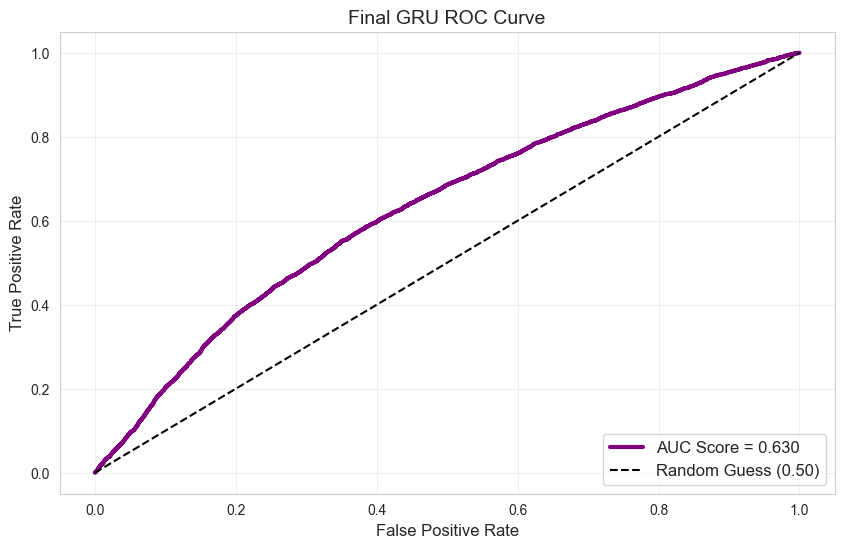

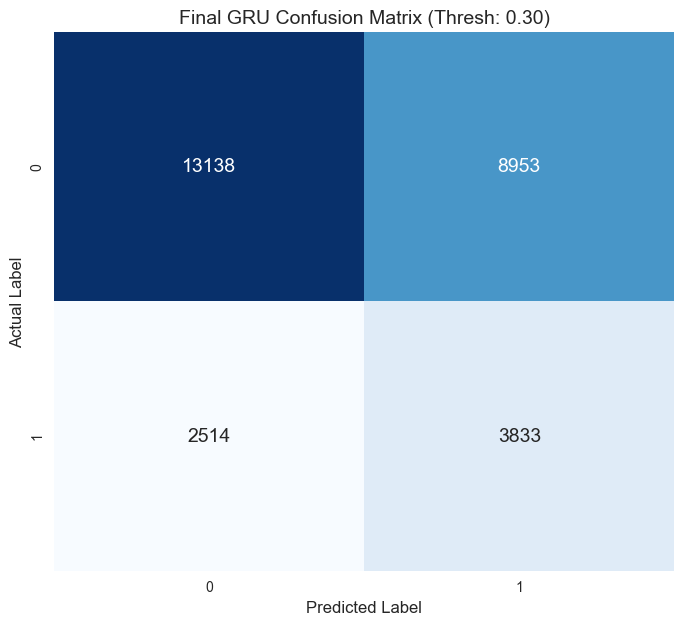

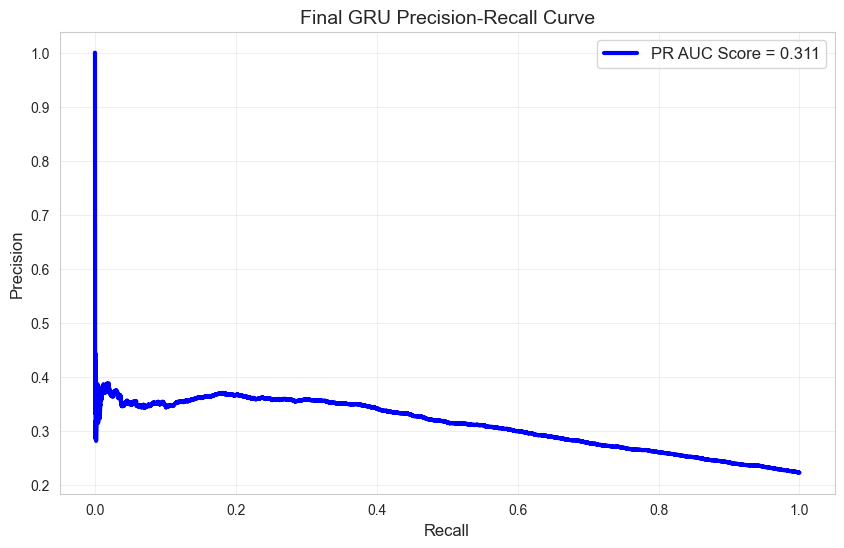

In [14]:
# ==========================================
# TASK 3 (Model 2): FINAL TUNED GRU MODEL
# ==========================================
import numpy as np
from sklearn.metrics import f1_score

print("--- TRAINING TUNED GRU (SMOTE + Threshold Opt) ---")

# 1. Tuned GRU Architecture (Stacked for "Deep" Learning)
model_gru_final = Sequential([
    GRU(64, return_sequences=True, input_shape=(n_timesteps, n_features)),
    Dropout(0.3),
    GRU(32, return_sequences=False),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Tuned Learning Rate
model_gru_final.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# 2. Train on SMOTE Data (X_train_smote_3d must exist from your previous runs)
history_gru_final = model_gru_final.fit(X_train_smote_3d, y_train_smote, 
                                        epochs=30, 
                                        batch_size=64, 
                                        validation_data=(X_test, y_test), 
                                        verbose=1)

# 3. Optimize Threshold
print("Optimizing GRU Decision Threshold...")
y_probs_gru = model_gru_final.predict(X_test)
best_thresh_gru = 0.5
best_f1_gru = 0.0

# Loop to find best F1 score
for thresh in np.arange(0.1, 0.6, 0.01):
    y_temp = (y_probs_gru > thresh).astype(int)
    score = f1_score(y_test, y_temp)
    if score > best_f1_gru:
        best_f1_gru = score
        best_thresh_gru = thresh

print(f"Best GRU Threshold Found: {best_thresh_gru:.2f}")
y_pred_gru_final = (y_probs_gru > best_thresh_gru).astype(int)

# ==========================================
# PLOTTING (INDIVIDUAL PLOTS)
# ==========================================
print("\n" + "="*40)
print(f"FINAL GRU METRICS (Threshold {best_thresh_gru:.2f})")
print("="*40)
print(classification_report(y_test, y_pred_gru_final))

# --- PLOT 1: TRAINING HISTORY ---
plt.figure(figsize=(10, 6))
plt.plot(history_gru_final.history['accuracy'], label='Train Accuracy', color='green', linewidth=2)
plt.plot(history_gru_final.history['val_accuracy'], label='Val Accuracy', color='orange', linewidth=2)
plt.title('Final GRU Training History', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# --- PLOT 2: ROC CURVE ---
fpr, tpr, _ = roc_curve(y_test, y_probs_gru)
roc_auc = roc_auc_score(y_test, y_probs_gru)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='purple', linewidth=3, label=f'AUC Score = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (0.50)') 
plt.title('Final GRU ROC Curve', fontsize=14)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# --- PLOT 3: CONFUSION MATRIX ---
plt.figure(figsize=(8, 7))
cm = confusion_matrix(y_test, y_pred_gru_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 14})
plt.title(f'Final GRU Confusion Matrix (Thresh: {best_thresh_gru:.2f})', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.show()

# --- PLOT 4: PRECISION-RECALL CURVE ---
precision, recall, _ = precision_recall_curve(y_test, y_probs_gru)
pr_auc = auc(recall, precision)

plt.figure(figsize=(10, 6))
plt.plot(recall, precision, color='blue', linewidth=3, label=f'PR AUC Score = {pr_auc:.3f}')
plt.title('Final GRU Precision-Recall Curve', fontsize=14)
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()